# 4. Gene Embedding Extraction

Extract **cell / gene embeddings** from the new frozen-split masking checkpoint, **held-out test only**.

| Setting | Value |
|---|---|
| ckpt | `masking_split/...20260808_2325...epoch=49.ckpt` |
| split | `True` + frozen `--split_path` (test indices only) |
| context_mode | `True` (must match training) |
| GPUs | **1 GPU** (embedding dump is not DDP-safe) |
| outputs | sod2: `.../res/masking_split/embeddings` |

Metrics-only test lives in notebook 03 §3.4. This notebook does **not** report MLM loss (`return_embeddings=True` → `not_masked`).

### Recommended: `screen`

```bash
screen -S gene_emb_test
bash /home/stuke1/perturbgen/Perturbgen/docs/examples/run_extract_embeddings_sod2.sh
# Ctrl+A D to detach
```

Or run this notebook top → bottom (params → build cmd → launch).


## 4.1. Parameters

Update GPU id if 0 is busy. Keep `SPLIT_PATH` aligned with notebook 02 / 03.


In [1]:
import os
from pathlib import Path

WORKSPACE = Path("/home/stuke1/perturbgen")
REPO = WORKSPACE / "Perturbgen"
TOKENIZED = WORKSPACE / "T_perturb" / "tokenized_data" / "LPS_all_tps_2k"
SOD2_ROOT = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

# Single GPU for embedding extract (val.py also forces n_devices=1)
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_DIR"] = str(SOD2_ROOT / "wandb")
os.environ["TMPDIR"] = str(SOD2_ROOT / "tmp")
os.environ["MPLBACKEND"] = "Agg"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["HWLOC_COMPONENTS"] = "-gl"
os.environ["HWLOC_GL_LINUX_NVIDIA_DISABLE"] = "1"
os.environ.pop("DISPLAY", None)
os.environ.pop("WAYLAND_DISPLAY", None)

# New 50-epoch frozen-split ckpt (train/val/test from notebook 02 §2.6)
CKPT_MASKING_PATH = str(
    WORKSPACE
    / "T_perturb"
    / "res"
    / "masking_split"
    / "checkpoints"
    / "20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt"
)
SPLIT_PATH = str(
    TOKENIZED
    / "splits"
    / "stratified_cell_type_harmonized_seed42_80_10_10.pkl"
)

# Write embeddings to sod2; do not overwrite the old full-data masking extract
OUTPUT_DIR = str(
    SOD2_ROOT / "T_perturb" / "res"
    / "masking_split" / "embeddings"
)
assert OUTPUT_DIR.startswith("/mnt/sod2-project/csb4"), (
    f"OUTPUT_DIR must be on sod2, got {OUTPUT_DIR}"
)

SRC_DATASET = str(TOKENIZED / "dataset_2000_hvg_src" / "normal.dataset")
TGT_DATASET_FOLDER = str(TOKENIZED / "dataset_2000_hvg_tgt")
SRC_ADATA = str(TOKENIZED / "h5ad_pairing_2000_hvg_src" / "normal.h5ad")
TGT_ADATA_FOLDER = str(TOKENIZED / "h5ad_pairing_2000_hvg_tgt")
MAPPING_DICT_PATH = str(TOKENIZED / "token_id_to_genename_2000_hvg.pkl")
TOKENID_TO_ROWID = str(TOKENIZED / "tokenid_to_rowid_2000_hvg.pkl")

ENCODER_PATH = str(
    REPO
    / "pretraining_cohort"
    / "20250709_1223_cellgen_train_masking_lr_5e-05_wd_1e-06_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_42-epoch=00.ckpt"
)

BATCH_SIZE = 32
N_WORKERS = 0
PRED_TPS = ["1", "2", "3"]  # 1=90m, 2=6h, 3=10h
VAR_LIST = ["cell_pairing_index", "time_after_LPS", "cell_type_harmonized"]

ENCODER = "scmaskgit"
CONTEXT_MODE = "True"
MASK_SCHEDULER = "pow"
POS_ENCODING_MODE = "time_pos_sin"
D_MODEL = 768
D_FF = 32
NUM_LAYERS = 6

RETURN_EMBEDDINGS = "True"
RETURN_GENE_EMBS = "True"
GENE_EMBS_CONDITION = "time_after_LPS"
RETURN_ATTN = "False"
GENERATE = "False"

for p in (CKPT_MASKING_PATH, SPLIT_PATH, ENCODER_PATH, SRC_DATASET, SRC_ADATA, TOKENID_TO_ROWID):
    if not Path(p).exists():
        raise FileNotFoundError(p)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
ckpt_info = Path(OUTPUT_DIR) / "ckpt_info.txt"
ckpt_info.write_text(
    "\n".join([
        f"ckpt={CKPT_MASKING_PATH}",
        f"split_path={SPLIT_PATH}",
        "split=True (held-out test only)",
        "context_mode=True",
        "return_embeddings=True",
        "return_gene_embs=True",
        f"pred_tps={PRED_TPS}",
    ]) + "\n"
)
print("Wrote", ckpt_info)
Path(os.environ["WANDB_DIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["TMPDIR"]).mkdir(parents=True, exist_ok=True)

print("CKPT:", CKPT_MASKING_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])
print("context_mode:", CONTEXT_MODE, "| split: True (test only)")


Wrote /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings/ckpt_info.txt
CKPT: /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
SPLIT_PATH: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl
OUTPUT_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings
CUDA_VISIBLE_DEVICES: 7
context_mode: True | split: True (test only)


## 4.2. Build the command

`extract-embedding` → `perturbgen.val` → `trainer.test` on **test_indices** from `SPLIT_PATH`.


In [2]:
cmd = [
    "python", "-m", "perturbgen", "extract-embedding",
    "--test_mode", "masking",
    "--split", "True",
    "--split_path", SPLIT_PATH,
    "--context_mode", CONTEXT_MODE,
    "--return_embeddings", RETURN_EMBEDDINGS,
    "--return_gene_embs", RETURN_GENE_EMBS,
    "--gene_embs_condition", GENE_EMBS_CONDITION,
    "--return_attn", RETURN_ATTN,
    "--generate", GENERATE,
    "--ckpt_masking_path", CKPT_MASKING_PATH,
    "--output_dir", OUTPUT_DIR,
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--tokenid_to_rowid", TOKENID_TO_ROWID,
    "--batch_size", str(BATCH_SIZE),
    "--n_workers", str(N_WORKERS),
    "--pred_tps", *PRED_TPS,
    "--var_list", *VAR_LIST,
    "--encoder", ENCODER,
    "--encoder_path", ENCODER_PATH,
    "--mask_scheduler", MASK_SCHEDULER,
    "--pos_encoding_mode", POS_ENCODING_MODE,
    "--d_model", str(D_MODEL),
    "--d_ff", str(D_FF),
    "--num_layers", str(NUM_LAYERS),
    "--wandb_mode", "offline",
]

print(" ".join(cmd))


python -m perturbgen extract-embedding --test_mode masking --split True --split_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl --context_mode True --return_embeddings True --return_gene_embs True --gene_embs_condition time_after_LPS --return_attn False --generate False --ckpt_masking_path /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt --output_dir /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings --src_dataset /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_src/normal.dataset --tgt_dataset_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_tgt --src_adata /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_src/normal.h5ad --tgt_adata_folder /home/s

## 4.3. Launch

Expect log lines: `Loaded frozen split from ...` and `Number of samples in test set: 14811`.


In [3]:
import subprocess

assert "sod2-project" in OUTPUT_DIR, (
    f"Refusing to run: OUTPUT_DIR is not on sod2: {OUTPUT_DIR}"
)
assert Path(CKPT_MASKING_PATH).is_file()
assert Path(SPLIT_PATH).is_file()

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = os.environ["CUDA_VISIBLE_DEVICES"]
env["WANDB_MODE"] = "offline"
env["PYTHONUNBUFFERED"] = "1"

print("Launching extract-embedding on GPU", env["CUDA_VISIBLE_DEVICES"])
print("OUTPUT_DIR:", OUTPUT_DIR)
print(" ".join(cmd))

subprocess.run(cmd, check=True, cwd=str(WORKSPACE), env=env)
print("Done. Outputs under:", OUTPUT_DIR)


Launching extract-embedding on GPU 7
OUTPUT_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings
python -m perturbgen extract-embedding --test_mode masking --split True --split_path /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl --context_mode True --return_embeddings True --return_gene_embs True --gene_embs_condition time_after_LPS --return_attn False --generate False --ckpt_masking_path /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt --output_dir /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings --src_dataset /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_src/normal.dataset --tgt_dataset_folder /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/dataset_2000_hvg_tgt --src_adata

Seed set to 42
/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Loading 2_6h_LPS.h5ad...


/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Loading 1_90m_LPS.h5ad...


...

Define context_tps for testing


Restoring states from the checkpoint path at /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [7]
Loaded model weights from the checkpoint at /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Testing DataLoader 0:   1%|▏         | 6/462 [01:21<1:43:05,  0.07it/s]


Aborted!

Detected KeyboardInterrupt, attempting graceful shutdown ...


KeyboardInterrupt: 

In [1]:
import os
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score

In [2]:
h5ad_path = "/mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings/20260809-11:31_inference_embs_t[1, 2, 3]_scmaskgit_mpow.h5ad"
adata = ad.read_h5ad(h5ad_path)

print("adata shape:", adata.shape)
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))

required_obs = ["cell_type_harmonized", "time_after_LPS", "batch", "cell_idx"]
missing_obs = [k for k in required_obs if k not in adata.obs.columns]
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")
if "cls_embeddings" not in adata.obsm:
    raise KeyError("Expected 'cls_embeddings' in adata.obsm")

adata shape: (26856, 1856)
obs columns: ['cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx']
obsm keys: ['cls_embeddings']


In [3]:
adata_emb = ad.AnnData(X=adata.obsm["cls_embeddings"].copy(), obs=adata.obs.copy())

# Keep labels as strings for robust plotting and sklearn metrics.
for col in ["cell_type_harmonized", "time_after_LPS", "batch"]:
    adata_emb.obs[col] = adata_emb.obs[col].astype(str)

adata_emb

AnnData object with n_obs × n_vars = 26856 × 768
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'

In [4]:
sc.pp.neighbors(adata_emb, use_rep="X", n_neighbors=15, metric="cosine")
sc.tl.umap(adata_emb, min_dist=0.3, random_state=42)

# Optional clusters in embedding space (for quick unsupervised sanity check).
sc.tl.leiden(adata_emb, resolution=0.8, key_added="leiden_emb")

/tmp/ipykernel_2013950/2887419977.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_emb, resolution=0.8, key_added="leiden_emb")


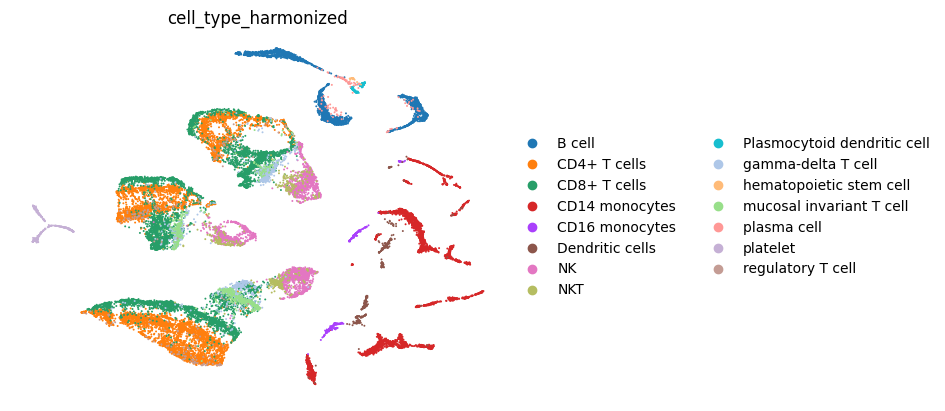

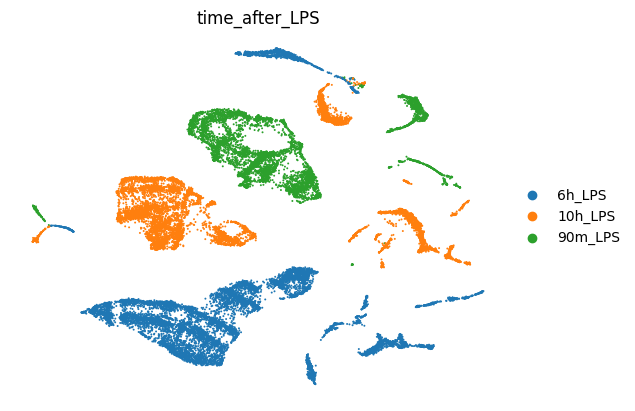

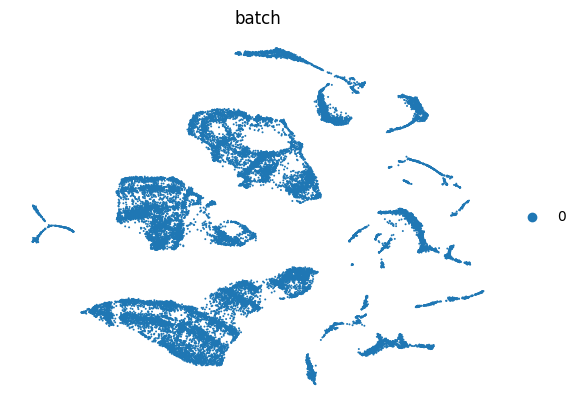

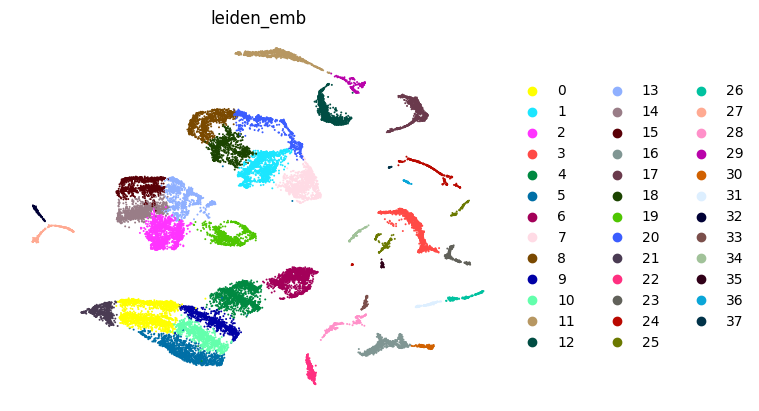

In [5]:
sc.pl.umap(adata_emb, color="cell_type_harmonized", frameon=False, size=8)
sc.pl.umap(adata_emb, color="time_after_LPS", frameon=False, size=8)
sc.pl.umap(adata_emb, color="batch", frameon=False, size=8)
sc.pl.umap(adata_emb, color="leiden_emb", frameon=False, size=8)

In [9]:
fig_dir = "/mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings/figures"
os.makedirs(fig_dir, exist_ok=True)

sc.pl.umap(adata_emb, color="cell_type_harmonized", show=False)
plt.savefig(f"{fig_dir}/umap_cell_type.png", dpi=200, bbox_inches="tight")
plt.close()

sc.pl.umap(adata_emb, color="time_after_LPS", show=False)
plt.savefig(f"{fig_dir}/umap_time_after_LPS.png", dpi=200, bbox_inches="tight")
plt.close()

sc.pl.umap(adata_emb, color="batch", show=False)
plt.savefig(f"{fig_dir}/umap_batch.png", dpi=200, bbox_inches="tight")
plt.close()

sc.pl.umap(adata_emb, color="leiden_emb", show=False)
plt.savefig(f"{fig_dir}/umap_leiden_emb.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved figures under:", fig_dir)

## 4.4. Quantitative embedding diagnostics

These checks complement UMAP visuals with numbers:
- **Cell type separability** (5-fold linear probe accuracy)
- **Time separability** (5-fold linear probe accuracy)
- **Batch leakage** (5-fold linear probe accuracy; lower is usually better)
- **Silhouette score** by cell type (higher is better)

Interpretation guideline:
- strong cell-type/time + weak batch = good biological embedding
- very strong batch signal may indicate technical leakage

In [ ]:
X = adata_emb.X

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, n_jobs=-1, multi_class="auto"),
)

def cv_acc(y):
    scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return float(scores.mean()), float(scores.std())

ct_mean, ct_std = cv_acc(adata_emb.obs["cell_type_harmonized"].values)
tp_mean, tp_std = cv_acc(adata_emb.obs["time_after_LPS"].values)
bt_mean, bt_std = cv_acc(adata_emb.obs["batch"].values)

# Silhouette can be expensive; subsample if very large.
max_sil_cells = 10000
if adata_emb.n_obs > max_sil_cells:
    rng = np.random.default_rng(42)
    idx = rng.choice(adata_emb.n_obs, size=max_sil_cells, replace=False)
    X_sil = X[idx]
    y_sil = adata_emb.obs["cell_type_harmonized"].values[idx]
else:
    X_sil = X
    y_sil = adata_emb.obs["cell_type_harmonized"].values

sil = silhouette_score(X_sil, y_sil, metric="cosine")

summary = pd.DataFrame(
    {
        "metric": [
            "cell_type_cv_accuracy",
            "time_after_LPS_cv_accuracy",
            "batch_cv_accuracy",
            "cell_type_silhouette_cosine",
        ],
        "value": [ct_mean, tp_mean, bt_mean, float(sil)],
        "std": [ct_std, tp_std, bt_std, np.nan],
    }
)
summary

In [ ]:
metrics_out = Path(OUTPUT_DIR) / "embedding_quality_summary.csv"
summary.to_csv(metrics_out, index=False)
print("Saved:", metrics_out)
summary

In [6]:
import pickle
import anndata as ad

split_path = "/home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl"
h5ad_path  = "/home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/h5ad_pairing_2000_hvg_tgt/1_90m_LPS.h5ad"

with open(split_path, "rb") as f:
    split = pickle.load(f)

test_idx = split["test_indices"]
adata = ad.read_h5ad(h5ad_path)
obs_test = adata.obs.iloc[test_idx]

print(len(test_idx))
display(obs_test[["cell_pairing_index","time_after_LPS","cell_type_harmonized","batch"]].head(20))
display(obs_test["cell_type_harmonized"].value_counts().head(15))
display(obs_test["batch"].value_counts())

14811


/home/stuke1/perturbgen/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


,cell_pairing_index,time_after_LPS,cell_type_harmonized,batch
76611,76611,90m_LPS,B cell,0
76049,76049,90m_LPS,B cell,0
76542,76542,90m_LPS,B cell,0
149365,149365,90m_LPS,B cell,1
126877,126877,90m_LPS,B cell,1
149441,149441,90m_LPS,B cell,1
76215,76215,90m_LPS,B cell,0
149865,149865,90m_LPS,B cell,1
149657,149657,90m_LPS,B cell,1
149823,149823,90m_LPS,B cell,1


cell_type_harmonized
CD4+ T cells                   4226
CD8+ T cells                   3023
CD14 monocytes                 2136
NK                             1799
B cell                         1086
gamma-delta T cell              695
mucosal invariant T cell        495
CD16 monocytes                  408
Dendritic cells                 275
NKT                             212
platelet                        178
regulatory T cell               125
Plasmocytoid dendritic cell      98
plasma cell                      45
hematopoietic stem cell          10
Name: count, dtype: int64

batch
0    10453
1     4358
Name: count, dtype: int64